# IMS: vibration snapshots and bearing degradation

Explore three bearing experiments at two distinct time scales: high-frequency
vibration **within a recording**, and the evolution of those recordings over
days. Experiment 1 has eight accelerometer channels (two per bearing);
experiments 2 and 3 have four (one per bearing).

[NASA source](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/)
· [Dataset guide](../../pdmdata/datasets/ims/README.md)

Run `pdmdata.download("ims")` explicitly if needed. It downloads the NASA-linked
ZIP and extracts its nested 7z and RAR files. This notebook reads local data.
Recording indices are zero-based within each experiment. All figures are saved
Matplotlib outputs that GitHub can display without running Python.


In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pdmdata").is_dir())
sys.path.insert(0, str(ROOT))
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import display
import pdmdata
from pdmdata.datasets.ims import inventory, load, channel_info, rms_history
from pdmdata.datasets.ims.viz import plot_waveforms, plot_rms

files = inventory()
summary = files.group_by("experiment").agg(
    pl.len().alias("recordings"), pl.col("channels").first(),
    pl.col("recording_time").min().alias("first_recording"),
    pl.col("recording_time").max().alias("last_recording"),
    pl.col("bytes").sum(),
).sort("experiment")
display(summary)
print(f"Local snapshots: {files.height:,}")


experiment,recordings,channels,first_recording,last_recording,bytes
u8,u32,u8,datetime[μs],datetime[μs],i64
1,2156,8,2003-10-22 12:06:24,2003-11-25 23:39:56,2477767237
2,984,4,2004-02-12 10:32:39,2004-02-19 06:22:39,544618480
3,6324,4,2004-03-04 09:27:46,2004-04-18 02:42:55,3502648779


Local snapshots: 9,464


## Channel assignments and end-of-test outcomes

The source describes inner-race damage in bearing 3 and roller-element damage
in bearing 4 of experiment 1; outer-race failure in bearing 1 of experiment 2;
and outer-race failure in bearing 3 of experiment 3. These descriptions are
experiment outcomes, not ground-truth onset times. "Not reported" does not
assert that every sample of another bearing is healthy.


In [2]:
for experiment in (1, 2, 3):
    print(f"Experiment {experiment}")
    display(channel_info(experiment))
# Eight-dimensional sensor-only input from experiment 1.
eight_channels = load(0, experiment=1).select(channel_info(1)["channel"].to_list())
print("Experiment 1 sensor matrix:", eight_channels.shape)


Experiment 1


channel,bearing,end_of_test_fault
str,i64,str
"""channel_1""",1,"""not reported"""
"""channel_2""",1,"""not reported"""
"""channel_3""",2,"""not reported"""
"""channel_4""",2,"""not reported"""
"""channel_5""",3,"""inner race"""
"""channel_6""",3,"""inner race"""
"""channel_7""",4,"""roller element"""
"""channel_8""",4,"""roller element"""


Experiment 2


channel,bearing,end_of_test_fault
str,i64,str
"""channel_1""",1,"""outer race"""
"""channel_2""",2,"""not reported"""
"""channel_3""",3,"""not reported"""
"""channel_4""",4,"""not reported"""


Experiment 3


channel,bearing,end_of_test_fault
str,i64,str
"""channel_1""",1,"""not reported"""
"""channel_2""",2,"""not reported"""
"""channel_3""",3,"""outer race"""
"""channel_4""",4,"""not reported"""


Experiment 1 sensor matrix: (20480, 8)


## Select snapshots from experiment 2

Select its first and last recording by index. An exact timestamp filename also
works, for example `load("2004.02.12.10.32.39", experiment=2)`.

The source reports 20,480 samples at 20 kHz and describes each file as a
one-second snapshot. Here the nominal axis is `sample / 20000`, corresponding
to 1.024 seconds for 20,480 sample periods (last sample at 1.02395 s). We retain
that stated sampling rate rather than silently changing it to 20.48 kHz.
Source amplitudes are retained without conversion; the bundled description
does not specify their numerical unit.


recording_index,recording,channels
u32,str,u8
0,"""2004.02.12.10.32.39""",4
983,"""2004.02.19.06.22.39""",4


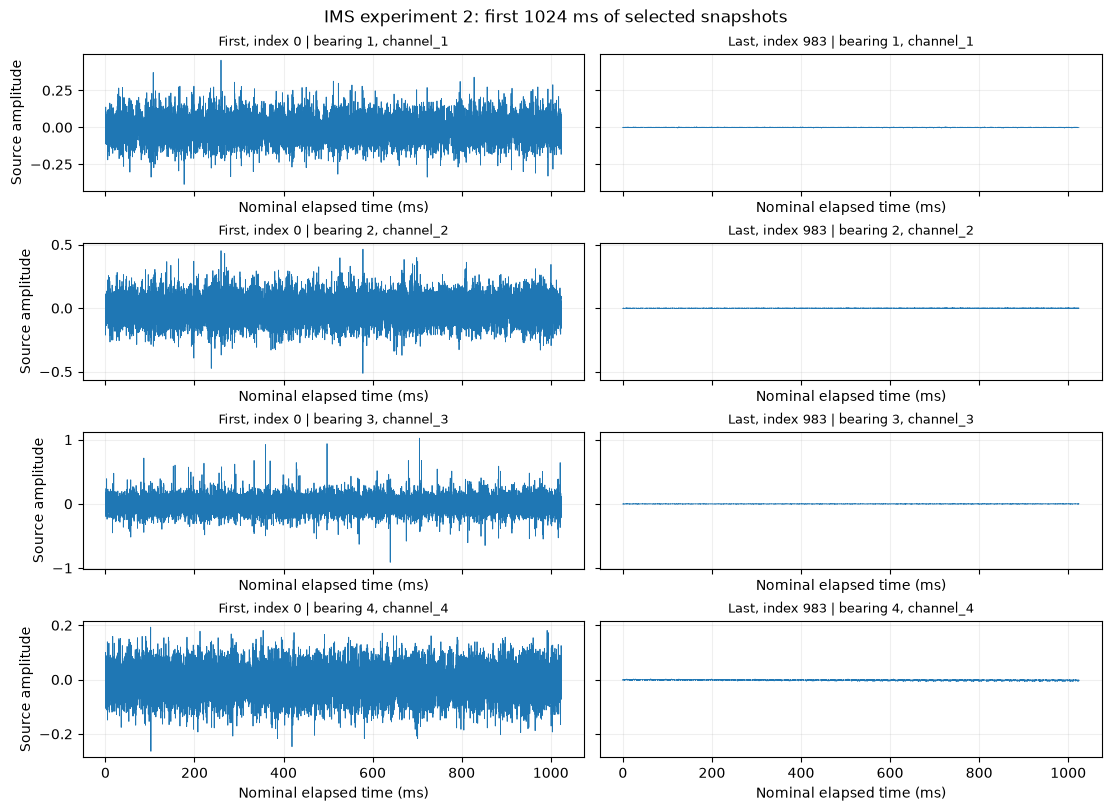

In [3]:
EXPERIMENT = 2
selected = inventory(EXPERIMENT)
first_index, last_index = 0, selected.height - 1
early = load(first_index, experiment=EXPERIMENT)
late = load(last_index, experiment=EXPERIMENT)
display(selected[[first_index, last_index]].select("recording_index", "recording", "channels"))
examples = [(f"First, index {first_index}", early), (f"Last, index {last_index}", late)]
full = plot_waveforms(examples, experiment=EXPERIMENT, stop_s=1.024)
plt.show()


## Zoom: first recording versus maximum channel 1 RMS

The final two recordings have near-zero amplitudes across all four channels.
This observation does not establish a healthy state or an annotated failure
onset. To also show a high-vibration example, select the recording with the
largest channel 1 RMS across experiment 2 (index 979 in this archive).

The same amplitude limits are used for a channel across both columns. This
explicit extreme-value selection is an illustration, not a representative
sample or a labeled segmentation benchmark.


recording_index,recording
u32,str
0,"""2004.02.12.10.32.39"""
979,"""2004.02.19.05.42.39"""
983,"""2004.02.19.06.22.39"""


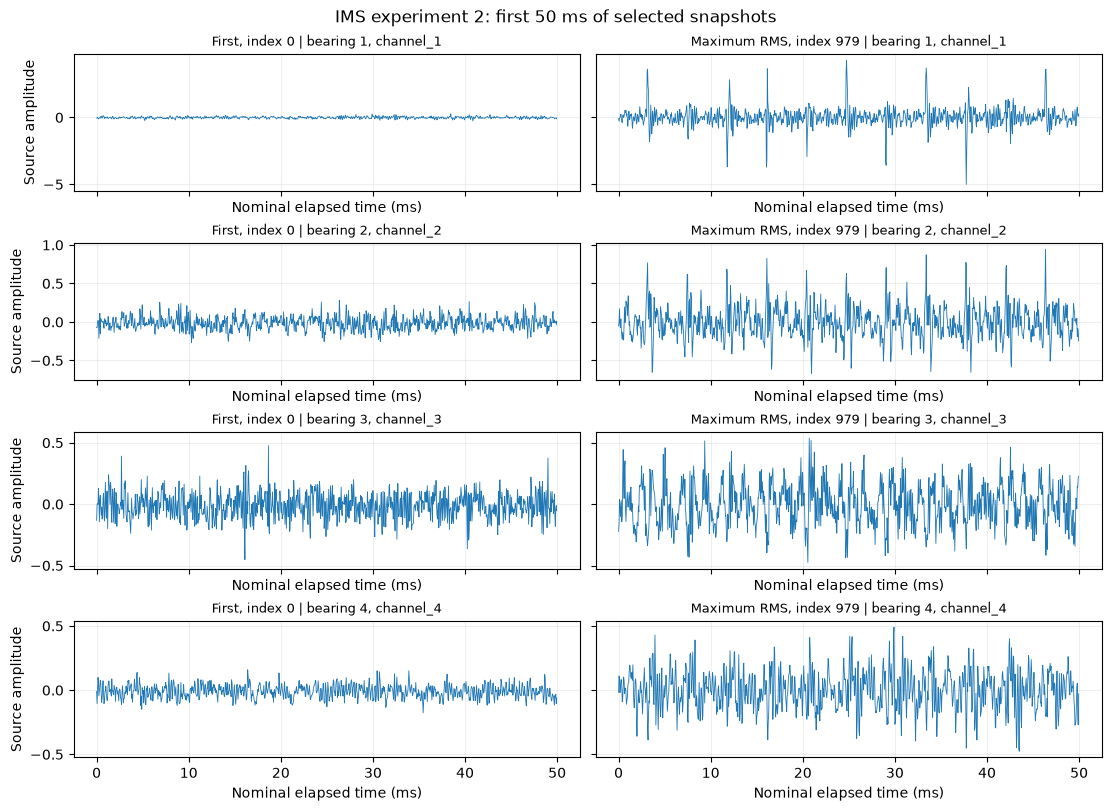

Sensor-only matrix for one snapshot: (20480, 4)


In [4]:
history = rms_history(EXPERIMENT)
peak_index = int(history.sort("channel_1", descending=True)["recording_index"][0])
peak = load(peak_index, experiment=EXPERIMENT)
examples = [("First, index 0", early), (f"Maximum RMS, index {peak_index}", peak)]
display(selected[[first_index, peak_index, last_index]].select("recording_index", "recording"))
zoom = plot_waveforms(examples, experiment=EXPERIMENT, stop_s=0.05)
assets = ROOT / "pdmdata/datasets/ims/assets"
assets.mkdir(parents=True, exist_ok=True)
zoom.savefig(assets / "waveforms.png", dpi=100)
plt.show()
X = early.select(channel_info(EXPERIMENT)["channel"].to_list())
print("Sensor-only matrix for one snapshot:", X.shape)


## Slow evolution: RMS for each recording

`rms_history` reads one snapshot at a time and computes sqrt(mean(x²)) per
channel without removing the mean. Points below cover **every recording** of
experiment 2. The horizontal axis uses actual filename timestamps, preserving
long acquisition gaps. RMS is an aggregate feature, not a fault label.

Recordings are normally about ten minutes apart; the first 43 recordings of
experiment 1 were taken about five minutes apart. Do not join snapshots into
a continuous 20 kHz waveform across the unobserved intervals.


recording_index,recording_time,channel_1,channel_2,channel_3,channel_4
i64,datetime[μs],f64,f64,f64,f64
978,2004-02-19 05:32:39,0.386975,0.176702,0.139409,0.143399
979,2004-02-19 05:42:39,0.725001,0.218294,0.170577,0.148351
980,2004-02-19 05:52:39,0.462012,0.170817,0.177878,0.11663
981,2004-02-19 06:02:39,0.483835,0.193641,0.187405,0.130582
982,2004-02-19 06:12:39,0.002103,0.004018,0.00395,0.002154
983,2004-02-19 06:22:39,0.001533,0.001239,0.001197,0.002124


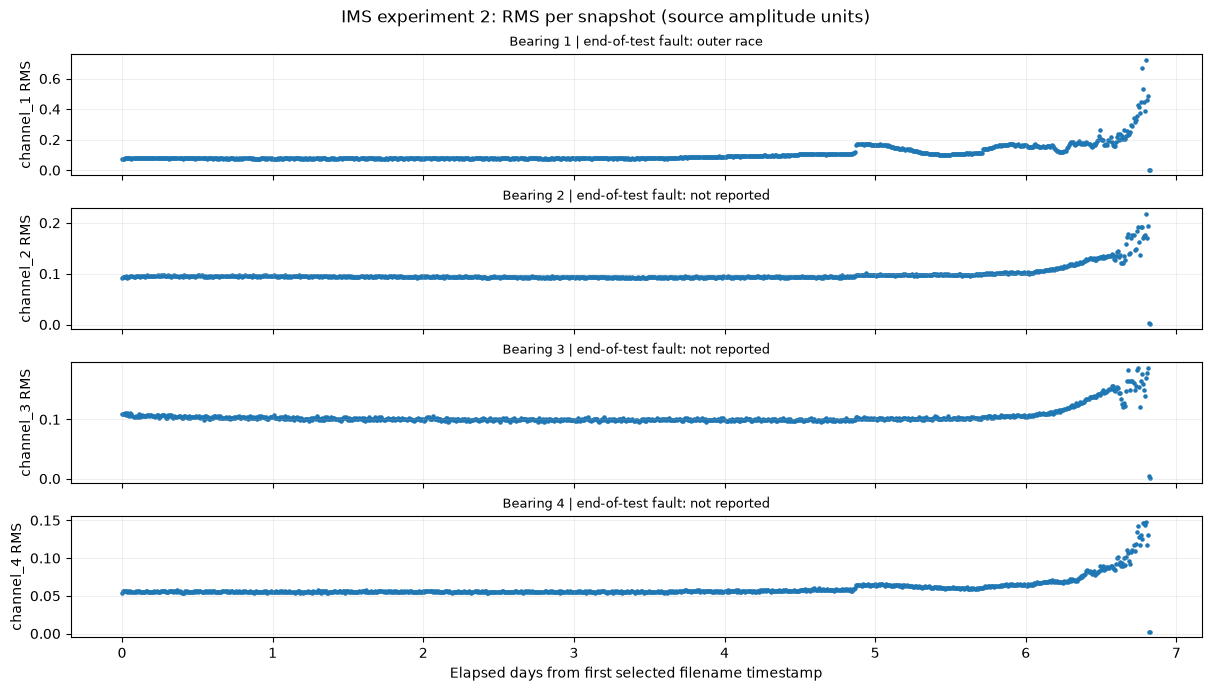

minimum_gap_s,median_gap_s,maximum_gap_s
i64,f64,i64
600,600.0,600


In [5]:
display(history.tail(6))
trend = plot_rms(history, experiment=EXPERIMENT)
plt.show()
intervals = selected.select(pl.col("recording_time").diff().dt.total_seconds().alias("gap_s")).drop_nulls()
display(intervals.select(pl.min("gap_s").alias("minimum_gap_s"),
                         pl.median("gap_s").alias("median_gap_s"),
                         pl.max("gap_s").alias("maximum_gap_s")))


## Experiment 3: archive contents differ from the bundled description

The supplied PDF describes 4,448 recordings ending on April 4, 2004. The
NASA-linked archive instead contains 6,324 recordings under
`3rd_test/4th_test/txt`, ending on April 18, 2004. The loader preserves every
source recording and treats the nested `4th_test` directory as experiment 3;
it does not create a fourth experiment. The archive's extension is not
explained in the PDF, so its last timestamp should not automatically become
a verified failure endpoint for RUL experiments. The final archive snapshot
also has near-zero amplitudes; the original values are preserved below.


recording_index,recording,channels
u32,str,u8
0,"""2004.03.04.09.27.46""",4
6323,"""2004.04.18.02.42.55""",4


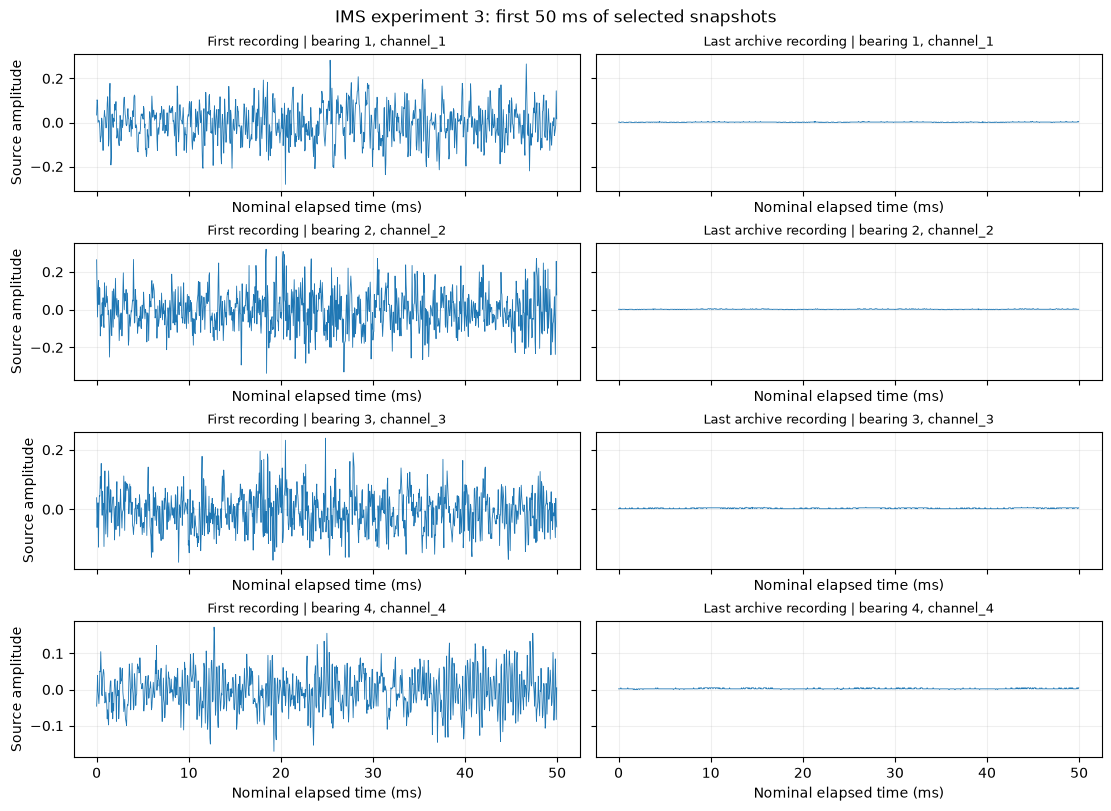

In [6]:
third = inventory(3)
third_examples = [("First recording", load(0, experiment=3)),
                  ("Last archive recording", load(third.height - 1, experiment=3))]
display(third[[0, third.height - 1]].select("recording_index", "recording", "channels"))
third_plot = plot_waveforms(third_examples, experiment=3, stop_s=0.05)
plt.show()


## Use in multiscale dependency research

- Choose 4 or 8 channels as the graph variables; do not flatten all 20,480 time
  samples into the feature dimension. Exclude identifiers and time columns.
- Fit scaling and any feature transformations on the training partition. Keep
  windows from one snapshot together and respect the experiment chronology.
- The short waveform scale and the multi-day degradation scale are distinct.
  RMS tracks may support slow-time modeling but discard within-recording phase.
- There are no supplied state-switching annotations. This dataset supports
  degradation studies more directly than supervised cyclic-state segmentation.
- End-of-test fault descriptions do not mark the exact start of a fault, and
  the three experiments are a small number of independent experimental runs.
- `verify()` reads every local matrix to check shape and finite values. The
  lightweight `inventory()` only inspects names and file sizes. Full validation
  results from dataset preparation are saved in the ignored raw-data directory.

Citation: J. Lee, H. Qiu, G. Yu, J. Lin, and Rexnord Technical Services (2007).
IMS, University of Cincinnati. *Bearing Data Set*, NASA Prognostics Data
Repository, NASA Ames Research Center. Technical details above are from the
bundled *Readme Document for IMS Bearing Data.pdf* and local archive inspection.
